# Dynamic Panel Models example

This notebook demonstrates usage of the DynamicPanelModels package on the EmplUK dataset.

First, we load the necessary libraries and download the EmplUK dataset from GitHub and load it into a DataFrame:

In [56]:
# libraries
using DynamicPanelModels
using DataFrames
using CSV
using Downloads
using Plots
using Statistics
using LinearAlgebra

In [57]:
# Load example dataset (EmplUK - Arellano & Bond, 1991)
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/plm/EmplUK.csv"
df = CSV.read(Downloads.download(url), DataFrame);

## Data exploration

Show the basic summary statistics of the dataset and the first rows.

In [58]:
show(describe(df), allrows=true, allcols=true)
first(df, 5)

8×7 DataFrame
 Row │ variable  mean        min        median    max        nmissing  eltype   
     │ Symbol    Float64     Real       Float64   Real       Int64     DataType 
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ rownames   516.0         1        516.0    1031              0  Int64
   2 │ firm        73.2037      1         74.0     140              0  Int64
   3 │ year      1979.65     1976       1980.0    1984              0  Int64
   4 │ sector       5.12318     1          5.0       9              0  Int64
   5 │ emp          7.89168     0.104      2.287   108.562          0  Float64
   6 │ wage        23.9188      8.0171    24.006    45.2318         0  Float64
   7 │ capital      2.50743     0.0119     0.518    47.1079         0  Float64
   8 │ output     103.801      86.9      100.55    128.365          0  Float64

Row,rownames,firm,year,sector,emp,wage,capital,output
,Int64,Int64,Int64,Int64,Float64,Float64,Float64,Float64
1,1,1,1977,7,5.041,13.1516,0.5894,95.7072
2,2,1,1978,7,5.6,12.3018,0.6318,97.3569
3,3,1,1979,7,5.015,12.8395,0.6771,99.6083
4,4,1,1980,7,4.715,13.8039,0.6171,100.55
5,5,1,1981,7,4.093,14.2897,0.5076,99.5581


Check panel balance (observations per firm) and compute the correlation matrix for selected variables.

In [59]:
# Panel Balance Check
obs_per_firm = combine(groupby(df, :firm), nrow => :count)
println("Min years per firm: ", minimum(obs_per_firm.count))
println("Max years per firm: ", maximum(obs_per_firm.count))
println("Average years per firm: ", round(mean(obs_per_firm.count); digits=2))

# Correlation Matrix
vars_to_check = [:emp, :wage, :capital, :output]
cor_matrix = cor(Matrix(df[:, vars_to_check]))
println("\nCorrelation Matrix:")
DataFrame(cor_matrix, vars_to_check)

Min years per firm: 7
Max years per firm: 9
Average years per firm: 7.36

Correlation Matrix:


Row,emp,wage,capital,output
,Float64,Float64,Float64,Float64
1,1.0,-0.108722,0.824563,-0.0070509
2,-0.108722,1.0,0.00735514,0.0111773
3,0.824563,0.00735514,1.0,-0.0223786
4,-0.0070509,0.0111773,-0.0223786,1.0


## Estimations

Run Difference GMM (Arellano-Bond) for the model `emp ~ lag(emp) + wage + capital + output`.

In [60]:
## Difference GMM (Arellano-Bond)
model_diff = fit(DifferenceGMM(robust=true), df;
    formula = "emp ~ lag(emp) + wage + capital + output",
    id_col = :firm,
    time_col = :year,
);
display(model_diff)

# Diagnostic
println("\nDifference GMM Diagnostics:")
diagnose(model_diff)


══════════════════════════════════════════════════════════════════════════════
  Dynamic Panel Data Estimation
══════════════════════════════════════════════════════════════════════════════
  Method:                1-step DifferenceGMM
  Formula:               emp ~ lag(emp) + wage + capital + output
  Std. Errors:           Robust (cluster-sandwich)
──────────────────────────────────────────────────────────────────────────────
  Observations:                   751    Groups:                  140
  Instruments:                     28
──────────────────────────────────────────────────────────────────────────────
  Variable         Estimate   Std. Error    z-value   Pr(>|z|)
──────────────────────────────────────────────────────────────────────────────
  L.emp             0.32567      0.16185     2.0122     0.0442 *  
  wage             -0.41848      0.20858    -2.0063     0.0448 *  
  capital           1.18442      0.71056     1.6669     0.0955 .  
  output            0.27694      0.10


Difference GMM Diagnostics:
      GMM DIAGNOSTIC REPORT
Sargan J-test (validity):   stat =  478.287, p-val = 0.0000
AR(1) test (serial corr):   stat =    0.758, p-val = 0.4487
AR(2) test (serial corr):   stat =   -0.419, p-val = 0.6753
Jarque-Bera (normality):    stat = 31941.176, p-val = 0.0000
------------------------------------------------------------
OK: Instruments: 28, Groups: 140 (Ratio: 0.2)


Dict{Symbol, Any} with 5 entries:
  :sargan      => DynamicPanelTest("Sargan J-Test", 478.287, 24, 0.0)
  :ar1         => DynamicPanelTest("Arellano-Bond AR(1)", 0.757556, 0, 0.448717)
  :ar2         => DynamicPanelTest("Arellano-Bond AR(2)", -0.418819, 0, 0.67534…
  :pseudo_r2   => 0.168165
  :jarque_bera => DynamicPanelTest("Jarque-Bera", 31941.2, 2, 0.0)

Run System GMM (Blundell-Bond) for the model `emp ~ lag(emp) + wage + capital + output`.

In [61]:
## System GMM (Blundell-Bond)
model_sys = fit(SystemGMM(robust=true), df;
    formula = "emp ~ lag(emp) + wage + capital + output",
    id_col = :firm,
    time_col = :year
);
display(model_sys)

# Diagnostic
println("\nSystem GMM Diagnostics:")
diagnose(model_sys)


══════════════════════════════════════════════════════════════════════════════
  Dynamic Panel Data Estimation
══════════════════════════════════════════════════════════════════════════════
  Method:                1-step SystemGMM
  Formula:               emp ~ lag(emp) + wage + capital + output
  Std. Errors:           Robust (cluster-sandwich)
──────────────────────────────────────────────────────────────────────────────
  Observations:                  1502    Groups:                  140
  Instruments:                     35
──────────────────────────────────────────────────────────────────────────────
  Variable         Estimate   Std. Error    z-value   Pr(>|z|)
──────────────────────────────────────────────────────────────────────────────
  L.emp             0.69545      0.17517     3.9701     0.0001 ***
  wage             -0.75776      0.23503    -3.2241     0.0013 ** 
  capital           0.42813      0.34655     1.2354     0.2167    
  output            0.21520      0.07806 


System GMM Diagnostics:
      GMM DIAGNOSTIC REPORT
Sargan J-test (validity):   stat =  966.700, p-val = 0.0000
AR(1) test (serial corr):   stat =    0.993, p-val = 0.3209
AR(2) test (serial corr):   stat =    0.936, p-val = 0.3495
Jarque-Bera (normality):    stat = 1223.214, p-val = 0.0000
------------------------------------------------------------
OK: Instruments: 35, Groups: 140 (Ratio: 0.25)


Dict{Symbol, Any} with 5 entries:
  :sargan      => DynamicPanelTest("Sargan J-Test", 966.7, 31, 0.0)
  :ar1         => DynamicPanelTest("Arellano-Bond AR(1)", 0.99266, 0, 0.320876)
  :ar2         => DynamicPanelTest("Arellano-Bond AR(2)", 0.935606, 0, 0.349476)
  :pseudo_r2   => 0.869418
  :jarque_bera => DynamicPanelTest("Jarque-Bera", 1223.21, 2, 0.0)

## Diagnostics

Autocorrelation tests, Sargan J-test for overidentifying restrictions, Wald test, and residual checks.

In [62]:
# Arellano-Bond Autocorrelation Tests
id_vec = [row.id for row in model_diff.metadata[:panel_info]];
time_vec = [row.time for row in model_diff.metadata[:panel_info]];
ar1_res = ar_test(model_diff, 1, id_vec, time_vec);
ar2_res = ar_test(model_diff, 2, id_vec, time_vec);
println("Test Name: ", ar2_res.test_name)
println("AR(2) Stat: ", round(ar2_res.stat, digits=3))
println("AR(2) p-val: ", round(ar2_res.pvalue, digits=4))

Test Name: Arellano-Bond AR(2)
AR(2) Stat: -0.419
AR(2) p-val: 0.6753


In [63]:
# Sargan J-Test for Overidentifying Restrictions
sar_res = sargan_test(model_diff);
println("J-statistic: ", round(sar_res.stat, digits=3))
println("Degrees of Freedom: ", sar_res.dof)
println("Sargan p-value: ", round(sar_res.pvalue, digits=4))

J-statistic: 478.287
Degrees of Freedom: 24
Sargan p-value: 0.0


In [64]:
# Wald Test for Overall Significance
n_params = length(model_diff.coef);
R = Matrix{Float64}(I, n_params, n_params);
r = zeros(n_params);
wald_res = wald_test(model_diff, R, r);
println("Wald Stat: ", round(wald_res.stat, digits=3))
println("Wald p-val: ", round(wald_res.pvalue, digits=4))

Wald Stat: 93.117
Wald p-val: 0.0


In [65]:
# Goodness-of-Fit (Pseudo R²) & Proliferation Check
r2_val = goodness_of_fit(model_diff);
prolif_msg = check_proliferation(model_diff);
println("Pseudo R²: ", round(r2_val, digits=4))
println(prolif_msg)

Pseudo R²: 0.1682
OK: Instruments: 28, Groups: 140 (Ratio: 0.2)


In [66]:
# Residual Normality Test (Jarque-Bera)
jb_res = jarque_bera_test(model_diff);
println("JB Stat: ", round(jb_res.stat, digits=3))
println("JB p-val: ", round(jb_res.pvalue, digits=4))

JB Stat: 31941.176
JB p-val: 0.0


## Visualization

Examples function of all plots via dashboard and a Q-Q plot to check normality, residual plots, and histograms of residuals.

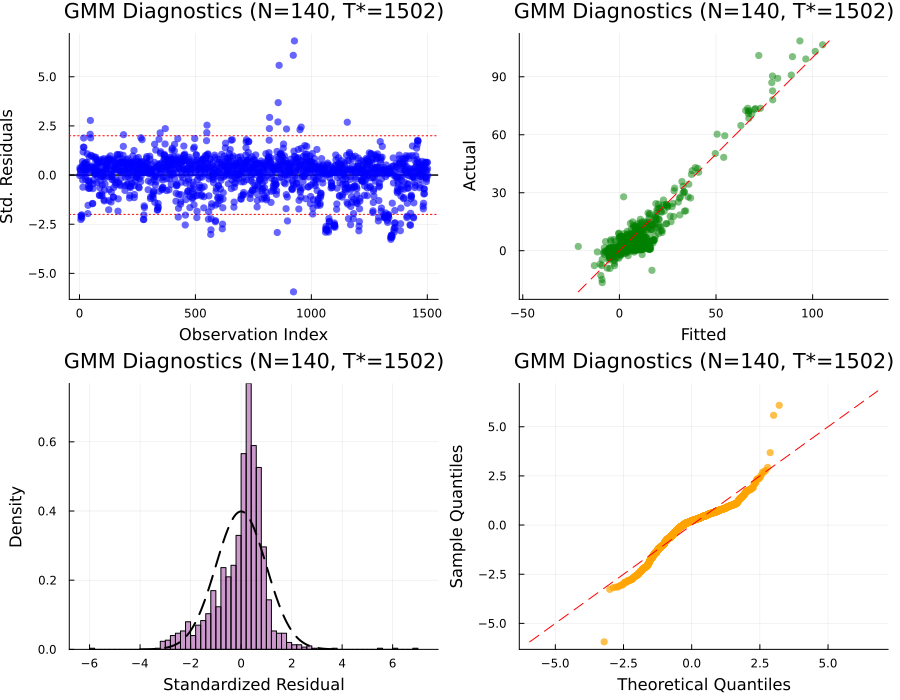

In [67]:
# All plots for System GMM model
plot(model_sys)

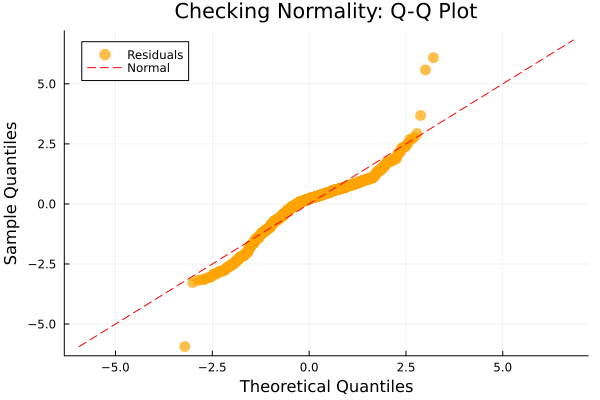

In [68]:
# Q-Q Plot of Residuals
plot(model_sys, :qq,
     title="Checking Normality: Q-Q Plot",
     markercolor=:orange,
     markersize=6)

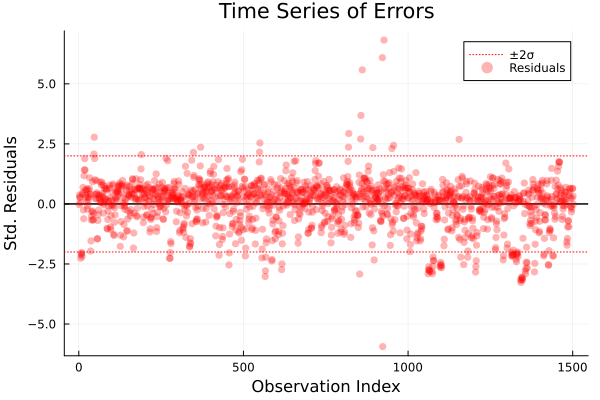

In [69]:
# Residuals vs Fitted Values
plot(model_sys, :residuals,
     title="Time Series of Errors",
     markercolor=:red,
     markeralpha=0.3)

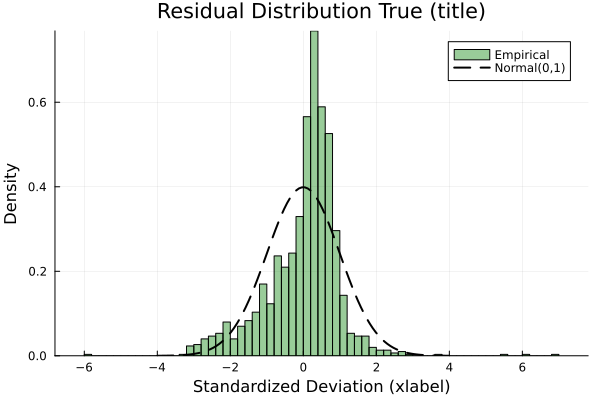

In [70]:
# Histogram of Residuals
plot(model_sys, :histogram,
     title="Residual Distribution True (title)",
     fillcolor=:green,
     xlabel="Standardized Deviation (xlabel)")